# SentimentScope: Sentiment Analysis using Transformers!
## Introduction <a name = "introduction"></a>

In this notebook, you will train a transformer model from scratch to perform sentiment analysis on the IMDB dataset. You are a Machine Learning Engineer at Cinescope, a growing entertainment company working to enhance its recommendation system. Your task is to fine-tune a transformer-based model for sentiment analysis using the IMDB dataset. By classifying reviews as positive or negative, you will help the company better understand user sentiment and deliver more personalized experiences.

By completing this project, you will demonstrate your competency in the following learning objectives:

- Load, explore, and prepare a text dataset for training a transformer model using PyTorch.
- Customize the architecture of the transformer model for a classification task.
- Train and test a transformer model on the IMDB dataset.

Now that you have an overview of what you will achieve in this project, let’s move on to the project outline.

---

### Project Outline

This notebook is organized into the following sections:


1. [Introduction](#introduction): Overview of the project, learning objectives, and understanding sentiment analysis.
2. [Load, Explore, and Prepare the Dataset](#load-explore-and-prepare-the-dataset): Load the IMDB dataset, explore it with visualizations, and split it into training and validation sets.
3. [Implement a DataLoader in PyTorch](#implement-a-dataloader-in-pytorch): Create the `IMDBDataset` class and use it with the PyTorch `DataLoader`, including tokenization.
4. [Customize the Transformer Architecture](#customize-the-transformer-architecture): Modify the transformer model for binary classification.
5. [Implement Accuracy Calculation Method](#implement-accuracy-calculation-method): Create a function to compute accuracy for monitoring performance.
6. [Train the Model](#train-the-model): Complete and execute the training loop for binary classification.
7. [Test the Model](#test-the-model): Evaluate the model on the test dataset and ensure it achieves over 75% accuracy.
8. [Conclusion](#conclusion): Summarize the project results and key takeaways.

Click on the section titles above to navigate directly to the corresponding part of the notebook!

---

Now that we've outlined the structure and objectives of this project, let's delve into the core concept: sentiment analysis.

### Understanding Sentiment Analysis

Sentiment analysis is a natural language processing (NLP) technique used to determine the sentiment expressed in a piece of text. This can range from identifying the polarity (positive, negative, or neutral) of a review to analyzing emotions and opinions.

In this project, sentiment analysis is explicitly framed as a **binary classification task**, where the goal is to determine whether a given movie review is *positive* or *negative*. This task is central to many real-world applications, including customer feedback analysis, social media monitoring, and recommendation systems. By developing a transformer-based model, you will classify IMDB movie reviews as positive or negative to tackle the challenge faced by your entertainment company CineScope by enhancing its recommendation system, enabling more accurate and personalized suggestions. 

Reviews labeled as positive will be marked as 1 in the dataset, while negative reviews will be labeled as 0.

For example, consider the following movie review:

> "The movie was a rollercoaster of emotions, and I loved every moment of it!"

This review is clearly positive as it expresses enjoyment and satisfaction with the movie, hence it will be labelled as *positive* or 1 in the dataset. In contrast:

> "The plot was predictable, and the acting was subpar. A waste of time."

This review conveys a negative sentiment, criticizing both the plot and acting, hence it will be labelled as *negative* or 0 in the dataset.

While transformers are often used for generation tasks, they can also be adapted for classification tasks with some modifications to their architecture. You might already be familiar with the tweaks that we will implement in this project.


---

### Data Description

The **IMDB Large Movie Review Dataset** (Maas et al., 2011) is the standard benchmark for binary sentiment classification. Key facts:

- **Size**: 50,000 movie reviews total, pulled from IMDB.
- **Labels**: Binary — positive or negative. There's no neutral class: reviews rated ≤4/10 are labeled negative, reviews rated ≥7/10 are labeled positive. Reviews in the 5–6 range (ambiguous) were excluded entirely.
- **Balance**: Perfectly balanced — 25,000 positive, 25,000 negative overall.
- **Provided split**: It comes pre-split into **25,000 train** / **25,000 test** reviews, each half itself balanced (12,500 pos / 12,500 neg).
- **No movie overlap trick**: No more than 30 reviews come from any single movie, and the train/test sets don't share the same movies — this stops the model from just memorizing "this movie = positive" instead of learning sentiment from language.
- **Raw text quirks**: Reviews are raw scraped text, so they contain leftover HTML like `<br /><br />` line breaks, punctuation, and varying lengths (the EDA in the notebook shows this — mean review length is a couple hundred words, with a long right tail of much longer reviews).

#### the Dataset can be get from

1. The dataset used in this project is the [IMDB dataset](https://ai.stanford.edu/~amaas/data/sentiment/), provided in the `aclIMDB_v1.tar.gz` file. 

Upon extracting the file, you will find the following folder structure:

```css
data/aclIMDB/
            ├── train/
            │   ├── pos/    # Positive reviews for training
            │   ├── neg/    # Negative reviews for training
            │   ├── unsup/  # Unsupervised data (not used in this project)
            ├── test/
            │   ├── pos/    # Positive reviews for testing
            │   ├── neg/    # Negative reviews for testing
```

- **train/**: Contains labeled data for training the model. Reviews in the `pos/` folder should be labeled as positive (1), while reviews in the `neg/` folder should be labeled as negative (0).
- **test/**: Contains labeled data for evaluating the model. Similar to the training data, `pos/` and `neg/` contain positive and negative reviews, respectively.
- **unsup/**: Contains unlabeled reviews that are not used in this project.

Understanding the folder structure is crucial as it guides how we load and preprocess the data for the sentiment classification task.

2. you can use the Hugging Face `datasets` library to load the IMDB dataset directly. Uncomment the following lines to load the dataset from Hugging Face:

```python

from datasets import load_dataset

# 25,000 / 25,000, pre-split by the dataset itself
train_df, test_df = load_dataset("imdb")

```

---


## <a name="load-explore-and-prepare-the-dataset"></a>Load, Explore, and Prepare the Dataset

### 1. Load the Dataset
The dataset is already available in the environment as `aclIMDB_v1.tar.gz`. We will load it into Pandas DataFrames for easy exploration and preparation.


In [1]:
import os
import pandas as pd

In [4]:
# Unpack the dataset - uncomment the line below to run
# !tar -xzf aclImdb_v1.tar.gz

You have successfully extracted the folder. Go back to your workspace and explore the folder structure and find the relative paths for each of the following:
- Training positive reviews
- Training negative reviews
- Testing positive reviews
- Testing negative reviews

Assign the paths of these folders relative to the starter file in the variables below.


In [2]:
# Define paths to dataset
train_pos_path = 'data/aclImdb/train/pos' # Path to the directory containing positive reviews from the training set
train_neg_path = 'data/aclImdb/train/neg' # Path to the directory containing negative reviews from the training set
test_pos_path = 'data/aclImdb/test/pos' # Path to the directory containing positive reviews from the test set
test_neg_path = 'data/aclImdb/test/neg' # Path to the directory containing negative reviews from the test set

Check if the paths are existing and valid. If they are not, use `datasets` module to download the dataset and extract it. You can use the following code snippet to check if the paths are valid:

```python
from pathlib import Path

dir_path = Path("/path/to/directory")

# Checks if it exists AND is a directory
if dir_path.is_dir():
    print("Directory exists!")
else:
    print("Directory does not exist.")
```


In [3]:
from pathlib import Path

LOCAL_DATA_PATH = True

for path in [train_pos_path, train_neg_path, test_pos_path, test_neg_path]:
    dir_path = Path(path)
    # Checks if it exists AND is a directory
    if dir_path.is_dir():
        print(f"Directory {path} exists!")
        LOCAL_DATA_PATH = LOCAL_DATA_PATH and True
    else:
        print(f"Directory {path} does not exist.")
        LOCAL_DATA_PATH = LOCAL_DATA_PATH and False
        
LOCAL_DATA_PATH


Directory data/aclImdb/train/pos exists!
Directory data/aclImdb/train/neg exists!
Directory data/aclImdb/test/pos exists!
Directory data/aclImdb/test/neg exists!


True

Now, you will implement the `load_dataset()` function, which reads all text files in a specified folder and returns their content as a list of strings. This function is essential for loading and preprocessing the dataset in subsequent steps.

To implement this function:

1. **Use the `os` module**: Leverage Python's `os` module to list all files in the folder.
2. **Handle file paths**: Use `os.path.join()` to construct full paths for files, ensuring compatibility across operating systems.
3. **Read file content**: Open each file in read mode (`'r'`) using UTF-8 encoding to handle text properly.
4. **Aggregate results**: Append the content of each file to a list and return it.

### Key Points to Consider:
- Ensure that the function only processes text files (you may use file extensions for filtering if needed).
- Refer to the [os.listdir documentation](https://docs.python.org/3/library/os.html#os.listdir) for listing files in a directory.


In [4]:
def load_dataset(folder):
    """
    Reads all text files in the specified folder and returns their content as a list.

    Args:
        folder (str): Path to the folder containing text files.

    Returns:
        list: A list of strings, where each string is the content of a text file.
    """
    reviews = []
    for filename in os.listdir(folder):
        if filename.endswith('.txt'):
            file_path = os.path.join(folder, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                reviews.append(f.read())
    return reviews

Use the function now to load the training and testing data:

In [5]:
LOCAL_DATA_PATH = False

# Load training and testing data
if LOCAL_DATA_PATH:
    train_pos = load_dataset(train_pos_path)
    train_neg = load_dataset(train_neg_path)
    test_pos = load_dataset(test_pos_path)
    test_neg = load_dataset(test_neg_path)
    # We can convert the data into pandas dataframes to make handling the datasets easier.
    # Create DataFrames
    train_df = pd.DataFrame({
        'review': train_pos + train_neg,
        'label': [1] * len(train_pos) + [0] * len(train_neg)
    })

    test_df = pd.DataFrame({
        'review': test_pos + test_neg,
        'label': [1] * len(test_pos) + [0] * len(test_neg)
    })

    print(train_df.head())
    
else:
    print("Local data path does not exist. Please check the paths and ensure the dataset is available.")
    # If the local data path does not exist, 
    # you can use the Hugging Face `datasets` library to load the IMDB dataset directly.
    # Uncomment the following lines to load the dataset from Hugging Face:

    from datasets import load_dataset
    
    raw = load_dataset("imdb")
    train_df = pd.DataFrame(raw["train"])
    train_df = train_df.rename(columns={"text": "review"})
    test_df = pd.DataFrame(raw["test"]).reset_index(drop=True)
    test_df = test_df.rename(columns={"text": "review"})
    
    print(train_df.head())


Local data path does not exist. Please check the paths and ensure the dataset is available.


c:\ProgramData\anaconda3\Lib\importlib\__init__.py:88: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.2)
  return _bootstrap._gcd_import(name[level:], package, level)


                                              review  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


You can ensure that your datasets have loaded correctly by running the following code cell. No output means success!

In [6]:
# Assert that both datasets have the expected number of rows
assert train_df.shape[0] == 25000, "Training dataset does not have 25000 rows."
assert test_df.shape[0] == 25000, "Testing dataset does not have 25000 rows."

# Assert that both datasets have exactly two columns
assert train_df.shape[1] == 2, "Training dataset does not have exactly 2 columns."
assert test_df.shape[1] == 2, "Testing dataset does not have exactly 2 columns."

### 2. Prepare the Dataset
We will split the training data further into training and validation subsets. The way we constructed the dataset, reviews with positive and negative labels are segregated. To ensure that the validation dataset works well, we first need to shuffle the dataset.

#### How it maps onto train / validation / test in this project

| Split | Size | Where it comes from | Used for |
|---|---|---|---|
| **Train** | ~22,500 reviews | 90% of the provided 25k train split (stratified) | Updating model weights each epoch |
| **Validation** | ~2,500 reviews | Held-out 10% of the provided 25k train split (stratified) | Checking loss/accuracy after each epoch, picking the best checkpoint, watching for overfitting |
| **Test** | 25,000 reviews | The dataset's own separate test split — untouched during training | Final, one-time accuracy check (must exceed 75%) |


In [7]:
'''
# Split train data into training and validation sets manually
train_size = int(0.9 * len(train_df))
# Shuffle the dataset
shuffled_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df = shuffled_df.iloc[:train_size]
val_df = shuffled_df.iloc[train_size:]
'''
# instead of a plain random split potentially skewing one class by chance,
# we can use sklearn's `train_test_split` function to split the training data into
# training and validation sets,
# stratify guarantees the validation split keeps the same label balance as the full training split

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

### 2. Explore the Dataset
Exploration helps us understand the dataset's structure and distribution.

Here are some suggestions for exploration and visualizations:
- **Dataset Overview**: Use `DataFrame.info()` and `DataFrame.describe()` to understand the dataset structure and basic statistics.
- **Label Distribution**: Create bar charts to visualize the number of positive and negative reviews.
- **Review Length Analysis**: Compute and plot the distribution of review lengths (e.g., number of characters or words).
- **Sample Reviews**: Print a few positive and negative reviews to understand the text content.

Write code to explore the dataset in this section.

#### Dataset Overview

In [8]:
print("Training Dataset overview:")
print("--------------------------")
print(train_df.info())

print("Validation Dataset overview:")
print("--------------------------")
print(val_df.info())

print("Test Dataset overview:")
print("--------------------------")
print(test_df.info())

Training Dataset overview:
--------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22500 entries, 0 to 22499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  22500 non-null  object
 1   label   22500 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 351.7+ KB
None
Validation Dataset overview:
--------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  2500 non-null   object
 1   label   2500 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 39.2+ KB
None
Test Dataset overview:
--------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  25000 non-null  object
 1   labe

In [10]:
# Descriptive Statistics (per split)
for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    df["review_len_words"] = df["review"].str.split().apply(len)
    df["review_len_chars"] = df["review"].str.len()

pd.concat(
    {
        "train": train_df["review_len_words"].describe(),
        "validation": val_df["review_len_words"].describe(),
        "test": test_df["review_len_words"].describe(),
    },
    axis=1,
)

,train,validation,test
count,22500.000000,2500.000000,25000.000000
mean,233.855244,233.174800,228.526680
std,173.816778,173.010928,168.883693
min,10.000000,18.000000,4.000000
25%,127.000000,127.000000,126.000000
50%,174.000000,172.000000,172.000000
75%,284.000000,284.250000,277.000000
max,2470.000000,1398.000000,2278.000000


#### Label Distribution

> Proving the Splits Are Balanced

In [11]:
def split_summary(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a small DataFrame summarizing size and label balance per split.
    """
    rows = []
    for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
        n = len(df)
        n_pos = int((df["label"] == 1).sum())
        n_neg = int((df["label"] == 0).sum())
        rows.append(
            {
                "split": name,
                "n_examples": n,
                "n_positive": n_pos,
                "n_negative": n_neg,
                "pct_positive": round(100 * n_pos / n, 2),
                "pct_negative": round(100 * n_neg / n, 2),
            }
        )
    return pd.DataFrame(rows)

In [12]:
summary = split_summary(train_df, val_df, test_df)
summary

,split,n_examples,n_positive,n_negative,pct_positive,pct_negative
0,train,22500,11250,11250,50.0,50.0
1,validation,2500,1250,1250,50.0,50.0
2,test,25000,12500,12500,50.0,50.0


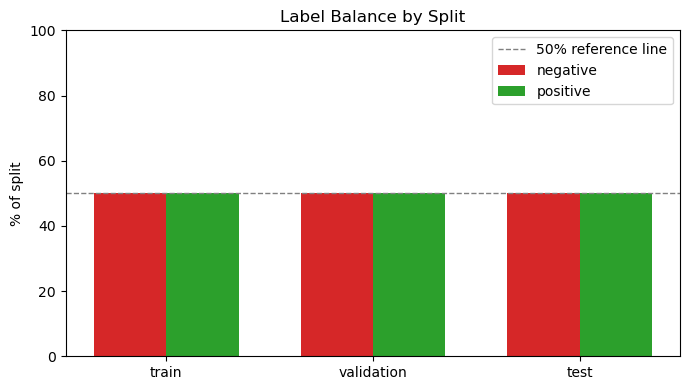

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Visual check `1`: does the 50/50 label balance hold across all three splits?
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(summary))
width = 0.35

ax.bar(x - width / 2, summary["pct_negative"], width, label="negative", color="#d62728")
ax.bar(x + width / 2, summary["pct_positive"], width, label="positive", color="#2ca02c")
ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="50% reference line")

ax.set_xticks(x)
ax.set_xticklabels(summary["split"])
ax.set_ylabel("% of split")
ax.set_ylim(0, 100)
ax.set_title("Label Balance by Split")
ax.legend()

plt.tight_layout()
plt.show()

#### Review Length Analysis

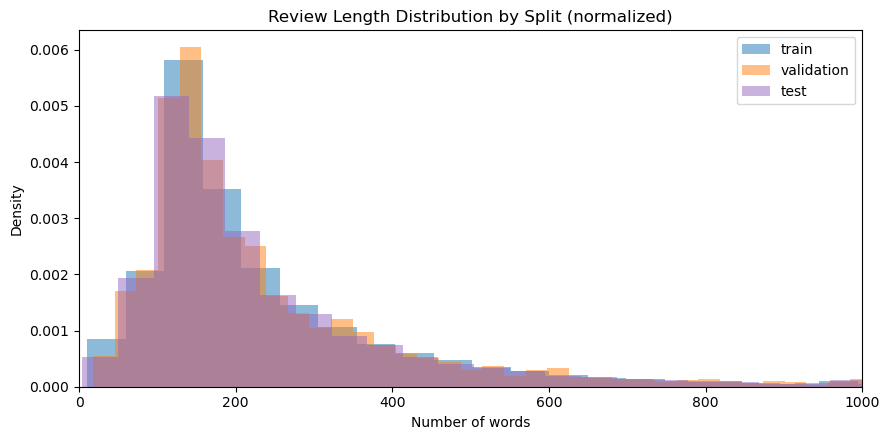

In [14]:
# Visual check `2`: 
# Review length distribution, overlaid across all three splits 
# -- are they drawn from the same underlying distribution, or 
# -- does one split skew differently
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {"train": "#1f77b4", "validation": "#ff7f0e", "test": "#9467bd"}
for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    ax.hist(df["review_len_words"], bins=50, alpha=0.5, density=True, label=name, color=colors[name])
ax.set_xlim(0, 1000)
ax.set_xlabel("Number of words")
ax.set_ylabel("Density")
ax.set_title("Review Length Distribution by Split (normalized)")
ax.legend()
plt.tight_layout()
plt.show()

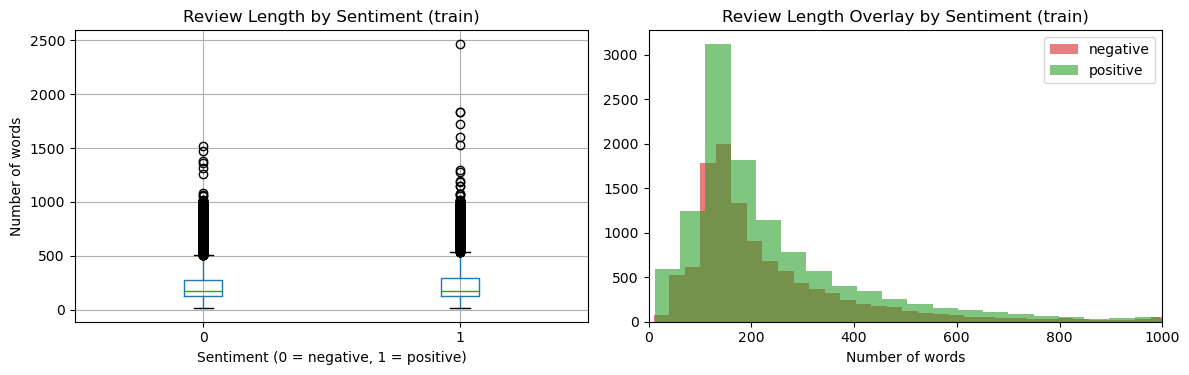

In [15]:
# Visual check `3`: 
# Review length by sentiment, within the training split specifically.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df.boxplot(column="review_len_words", by="label", ax=axes[0])
axes[0].set_title("Review Length by Sentiment (train)")
axes[0].set_xlabel("Sentiment (0 = negative, 1 = positive)")
axes[0].set_ylabel("Number of words")
plt.suptitle("")

axes[1].hist(
    train_df.loc[train_df["label"] == 0, "review_len_words"], bins=50, alpha=0.6, label="negative", color="#d62728"
)
axes[1].hist(
    train_df.loc[train_df["label"] == 1, "review_len_words"], bins=50, alpha=0.6, label="positive", color="#2ca02c"
)
axes[1].set_xlim(0, 1000)
axes[1].set_title("Review Length Overlay by Sentiment (train)")
axes[1].set_xlabel("Number of words")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Sample Reviews

In [16]:
train_df

,review,label,review_len_words,review_len_chars
0,"""Algie, the Miner"" is one bad and unfunny sile...",0,109,638
1,This is a complete Hoax...<br /><br />The movi...,0,162,867
2,"Nifty little episode played mainly for laughs,...",1,107,637
3,Perhaps the worst thing about Carlos Mencia's ...,0,119,714
4,"First of all, I firmly believe that Norwegian ...",0,306,1760
...,...,...,...,...
22495,The sopranos was probably the last best show t...,1,163,853
22496,"As part of our late 1950s vocabulary, we well ...",1,164,943
22497,Quite what the producers of this appalling ada...,0,401,2308
22498,"""Trigger Man"" is definitely the most boring an...",0,116,647


#### Data-quality checks

- missing values, 
- duplicate reviews,
- leftover HTML markup.

In [18]:
for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    n_missing = df[["review", "label"]].isna().sum().sum()
    n_duplicates = df["review"].duplicated().sum()
    n_html = df["review"].str.contains("<br", regex=False).sum()
    print(
        f"{name:12s} | missing={n_missing:5d} | "
        f"duplicates={n_duplicates:5d} ({n_duplicates / len(df):.2%}) | "
        f"html markup={n_html:5d} ({n_html / len(df):.2%})"
    )

train        | missing=    0 | duplicates=   75 (0.33%) | html markup=13163 (58.50%)
validation   | missing=    0 | duplicates=    2 (0.08%) | html markup= 1502 (60.08%)
test         | missing=    0 | duplicates=  199 (0.80%) | html markup=14535 (58.14%)


#### Most Common Words by Sentiment

In [20]:
import re
from collections import Counter

STOPWORDS = set(
    '''
    a an the and or but if while is are was were be been being this that these those
    to of in on at for with as by from it its it's he she they we you i my your his
    her their our not no so than then there here what which who whom will would can
    could should just also very br
    '''.split()
)


def get_word_counts(texts, top_n=20):
    counter = Counter()
    for t in texts:
        words = re.findall(r"[a-z']+", t.lower())
        words = [w for w in words if w not in STOPWORDS and len(w) > 2]
        counter.update(words)
    return counter.most_common(top_n)


pos_counts = get_word_counts(train_df.loc[train_df["label"] == 1, "review"], top_n=20)
neg_counts = get_word_counts(train_df.loc[train_df["label"] == 0, "review"], top_n=20)

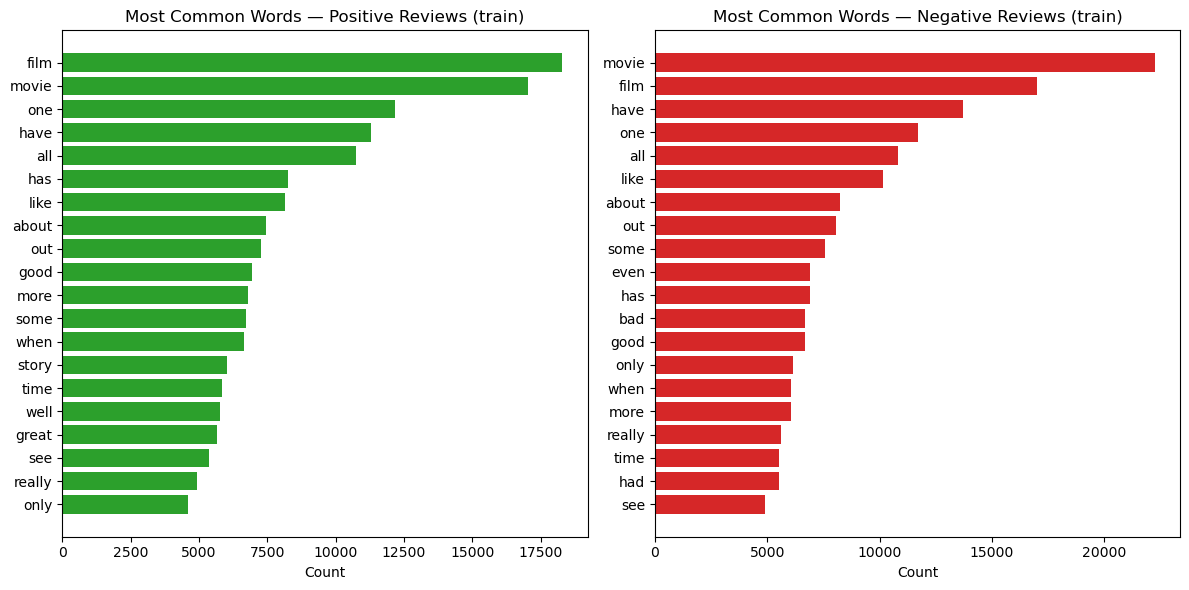

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

words, counts = zip(*pos_counts)
axes[0].barh(words, counts, color="#2ca02c")
axes[0].invert_yaxis()
axes[0].set_title("Most Common Words — Positive Reviews (train)")
axes[0].set_xlabel("Count")

words, counts = zip(*neg_counts)
axes[1].barh(words, counts, color="#d62728")
axes[1].invert_yaxis()
axes[1].set_title("Most Common Words — Negative Reviews (train)")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

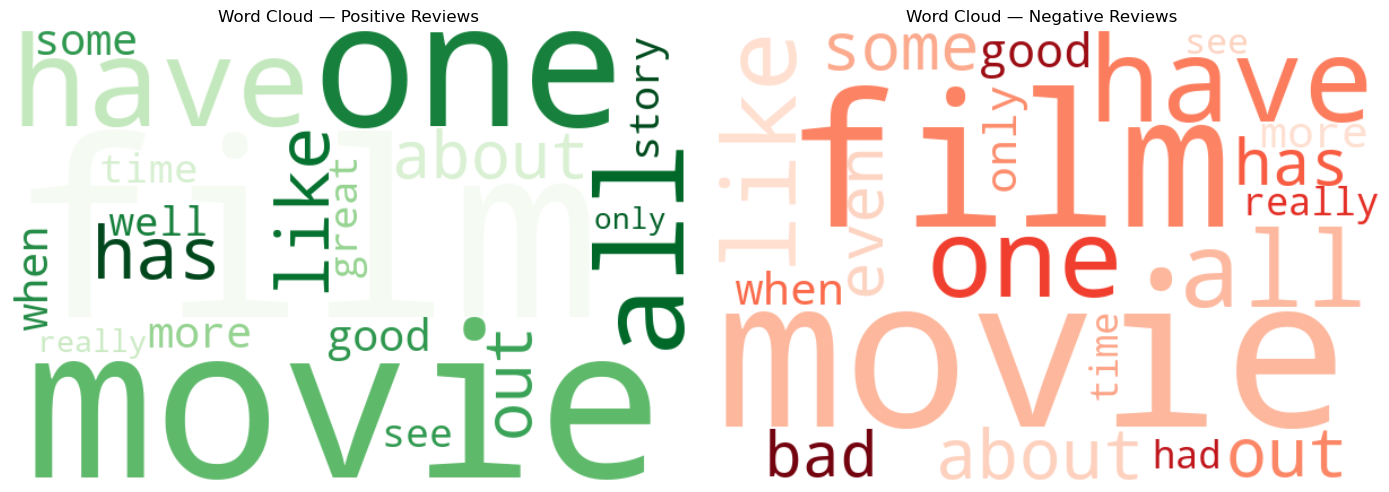

In [22]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, counts, title, cmap in [
        (axes[0], pos_counts, "Positive Reviews", "Greens"),
        (axes[1], neg_counts, "Negative Reviews", "Reds"),
    ]:
    
    wc = WordCloud(width=600, height=400, background_color="white", colormap=cmap).generate_from_frequencies(dict(counts))
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Word Cloud — {title}")
    ax.axis("off")
plt.tight_layout()
plt.show() 

#### EDA Conclusions

- **Dimensions verified:** `train_df` , `val_df`, `test_df`.
- **Balance verified two ways:** the `split_summary()` table shows ~50/50 positive/negative in all three splits.
- **Representativeness:** review length distributions overlap closely across train/validation/test.
- **Data-quality:** reviews contain leftover HTML markup (`<br />`) which the BERT tokenizer treats as ordinary subword tokens rather than something that needs stripping;duplicate rate is low enough not to warrant deduplication.

---


### 4. Testing the Tokenizer

#### Subword Tokenization
In earlier tasks, you might have encountered character-level tokenization, where each character in the text is treated as a token. While this is straightforward, it is less efficient and may result in larger input sizes, impacting the performance of transformer models.

To address this, we will use Hugging Face's `AutoTokenizer`, a robust and efficient class designed for tokenizing text based on pretrained models. Specifically, we will utilize the `bert-base-uncased` tokenizer, which applies **subword tokenization**. Subword tokenization involves two steps:

1. **Subword Splitting**: Words are split into smaller components (subwords) based on a predefined vocabulary. For example:
   - Input: "unhappiness"
   - Subword Splits: `['un', 'happiness']`

2. **Token Conversion**: Each subword is then converted into a numerical token ID. For example:
   - Subword Splits: `['un', 'happiness']`
   - Token IDs: `[1011, 24123]` (values are illustrative and depend on the tokenizer vocabulary).

#### About the `bert-base-uncased` Tokenizer
The `bert-base-uncased` tokenizer, developed by Google researchers, is part of the BERT model family. This tokenizer is associated with the `bert-base-uncased` model, which has been widely used for tasks such as sentiment analysis, question answering, and text classification. The tokenizer ensures all text is converted to lowercase and accents are removed, reducing vocabulary size and improving generalization. Example:

- Input: "I Love Transformers."
- Subword Splits: `['i', 'love', 'trans', '##formers', '.']`

You can learn more about the tokenizer and model on [Hugging Face's bert-base-uncased page](https://huggingface.co/bert-base-uncased).

#### Using the `AutoTokenizer` Class
The `AutoTokenizer` class in the Hugging Face Transformers library provides a seamless way to load tokenizers for various pretrained models. It automatically selects the correct tokenizer configuration based on the model name.


In [23]:
from transformers import AutoTokenizer

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

This initializes a tokenizer tailored for the `bert-base-uncased` model. You can refer to the [Hugging Face AutoTokenizer documentation](https://huggingface.co/docs/transformers/main_classes/tokenizer) for more details. You can find the definition of the `from_pretrained()` method [here](https://huggingface.co/docs/transformers/v4.48.0/en/model_doc/auto#transformers.AutoTokenizer.from_pretrained).

Instead of tokenizing the entire dataset, we will test the tokenizer on a few sample reviews directly from the dataset:


In [25]:
print(tokenizer.encode("Hello world"))
print(tokenizer.decode(tokenizer.encode("Hello world")))

[101, 7592, 2088, 102]
[CLS] hello world [SEP]


In [26]:
# Take sample inputs from the dataset
sample_texts = train_df['review'].sample(3, random_state=42).tolist()

# Tokenize sample inputs
tokenized_samples = tokenizer(
    sample_texts, 
    truncation=True, 
    padding="max_length", 
    max_length=128, 
    return_tensors="pt"
)

In [27]:
print(tokenized_samples)

{'input_ids': tensor([[  101,  2023,  3185,  2001,  9202,  1012,  1045,  2071,  4510,  2994,
          8300,  2083,  2009,  1012,  1045,  2052,  2196,  2156,  2023,  3185,
          2153,  2065,  1045,  2020,  3477,  2098,  2000,  1012,  1996,  2061,
          1011,  2170,  5469,  5019,  1999,  2009,  2020,  4297, 16416,  2850,
          6321, 21425,  1998,  2058,  2209,  1012,  2045,  2001,  2428,  2498,
          2055,  2023,  3185,  2008,  2052,  2031,  2081,  2009,  2434,  2030,
          4276,  1996,  1002,  1021,  1012,  2753,  1045,  3477,  2098,  2000,
          2156,  2009,  1012,  2123,  1005,  1056,  2175,  2156,  2009,  1010,
          2123,  1005,  1056,  9278,  2009,  1010,  2123,  1005,  1056,  3191,
          2055,  2009,  3784,  2138,  2151,  1997,  2122,  2477,  2052,  2022,
          1037,  3143,  5949,  1997,  2115,  2051,  1012,  4532,  9393, 21500,
          3917,  2435,  1037,  3768,  7393,  3334,  2836,  1998,  2428,  2323,
          2022, 14984,  1997,  2841,  

Explanation of parameters:
 - `truncation=True`: Truncates text longer than the specified max_length.
 - `padding=True`: Pads shorter sequences to match max_length.
 - `max_length=128`: Specifies the maximum length of the sequences.
 - `return_tensors="pt"`: Returns PyTorch tensors as the output format.
 
For more details about truncation and padding, refer to the [Hugging Face Padding and Truncation Documentation](https://huggingface.co/docs/transformers/pad_truncation). This step ensures that the tokenizer works as expected and provides insight into its behavior. Next, we will use the tokenizer within the class definition to process the dataset.

---


# Implement a DataLoader in PyTorch<a id="implement-a-dataloader-in-pytorch"></a>


In this section, you will implement a custom dataset class and use it to create a DataLoader in PyTorch for feeding data into the model during training. PyTorch simplifies this process by providing the `Dataset` and `DataLoader` classes, which handle batching, shuffling, and preprocessing, allowing you to focus on the model architecture and training.

To start, we will create a custom dataset class for the IMDB dataset, which will process and return tokenized inputs along with their corresponding labels. This class will use a tokenizer to preprocess the raw text data.

### 1. Define a Custom Dataset Class

The custom dataset class will inherit from `torch.utils.data.Dataset` and include the following features:

1. **Initialization (`__init__`)**:
   - Accepts raw text and label data, along with a tokenizer and a maximum sequence length.
   - The tokenizer is used to preprocess the text data into tokenized inputs.
   - The maximum sequence length ensures that all tokenized inputs are of uniform length.

2. **Length (`__len__`)**:
   - Returns the total number of data samples in the dataset.

3. **Item Retrieval (`__getitem__`)**:
   - Retrieves a single data point by index.
   - Preprocesses the text using the tokenizer to create tokenized input IDs.
   - Returns the tokenized input IDs and the corresponding label for the given index.

You can refer to [this](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) tutorial on the Pytorch website for more details.


In [70]:
import torch
from torch.utils.data import Dataset
MAX_LENGTH = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**NOTE ABOUT GPU USAGE**

The workspace provides you with access to a GPU which is necessary for training a transformer model due to the efficiency provided by GPUs on the large amount of computations that are required. To ensure judicious usage of limited resources, please usage the GPU only when you are training the model. 

---
We will keep the maximum length of input to 128 tokens.

In [71]:
from torch.utils.data import Dataset

class IMDBDataset(Dataset):
    """
    A custom PyTorch Dataset for the IMDB dataset.

    This class preprocesses text data using a tokenizer and returns tokenized inputs
    along with their corresponding labels for sentiment analysis.

    Attributes:
        data (pd.DataFrame): A DataFrame containing text and label columns.
        tokenizer (transformers.PreTrainedTokenizer): The tokenizer used for preprocessing text.
        max_length (int): Maximum length for tokenized sequences.
    """
    def __init__(self, data, tokenizer, max_length=MAX_LENGTH):
        """
        Initialize the dataset.

        Args:
            data (pd.DataFrame): A DataFrame with columns `review` (text) and `label` (target).
            tokenizer (transformers.PreTrainedTokenizer): The tokenizer to preprocess the text.
            max_length (int, optional): Maximum token sequence length. Defaults to 128.
        """
        #TODO: Write code to initialize the dataset
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        """
        Return the total number of samples in the dataset.

        Returns:
            int: Number of samples.
        """
        #TODO: Write code to return the length of the dataset
        return len(self.data)

    def __getitem__(self, idx):
        """
        Retrieve a single data point by index and preprocess it.

        Args:
            idx (int): Index of the data point to retrieve.

        Returns:
            torch.Tensor: Tokenized input IDs for the text.
            int: Label corresponding to the text.
        """
        #TODO: Write code for the __getitem__() function
        row = self.data.iloc[idx]
        text = row['review']
        label = row['label']

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze(0)

        return input_ids, label

### 2. Initialize the Dataset

Once the `IMDBDataset` class is defined, we can initialize it directly with the training and validation DataFrames.

In [72]:
# Initialize the datasets
train_dataset = IMDBDataset(train_df, tokenizer)
val_dataset   = IMDBDataset(val_df, tokenizer)
test_dataset  = IMDBDataset(test_df, tokenizer)

In [73]:
val_dataset

### 3. Create a DataLoader

The `DataLoader` class in PyTorch helps manage batches of data during training. We will use it to create training and validation data loaders.

In [74]:
from torch.utils.data import DataLoader

# Define batch size
BATCH_SIZE = 32

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [75]:
val_loader


You may have seen the use of `RandomShuffler` along with `DataLoader`. That approach is used when you want to train a model over a dataset randomly for a specified number of steps. In this model, we want to use the epoch approach.

An **epoch** is one complete pass through the entire dataset. When using the `DataLoader` in this setup, it ensures that every data point in the dataset is used exactly once during a single epoch. This approach is helpful for training models in a structured manner, ensuring that the model sees all the training examples and learns from them in each epoch before moving to the next one.

By setting `shuffle=True` for the `train_loader`, the data points are randomly shuffled at the start of each epoch, improving the generalization of the model. You will see this in action later in the code for training the model.

---
Given below are some assert statements to check your custom dataset and data loader definitions.

In [76]:
assert len(train_dataset) == 22500, "Train dataset length mismatch!"
assert len(val_dataset) == 2500, "Validation dataset length mismatch!"
assert len(test_dataset) == 25000, "Test dataset length mismatch!"

import numpy as np

# Check the first item in the train dataset
input_ids, label = train_dataset[0]
assert isinstance(input_ids, torch.Tensor), "Input IDs should be a torch.Tensor!"
assert isinstance(label, (int, np.integer)), "Label should be an integer or int-like!"

# Ensure the input IDs tensor has the correct shape
assert input_ids.shape[0] == train_dataset.max_length, "Input IDs tensor has incorrect length!"

## <a id="customize-the-transformer-architecture"></a>Customize the Transformer Architecture

In this section, you will customize the transformer architecture to suit the task of binary classification. You may have used a similar architecture in the past for generation tasks. But you will need to make a few tweaks specifically in the `DemoGPT` class to adapt it for the binary classification.

### 1. Config Dictionary
Your config dictionary bundles all hyperparameters and model settings in one place. Below is the config that we will use in our model:

In [77]:
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 128,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 4,
    "head_size": 32,  # 4 heads * 32 = 128 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}

Key Config Parameters:
- `vocabulary_size`: The total number of tokens in your vocabulary.
- `num_classes`: The number of classes for the classification head (2 = binary).
- `d_embed`: Dimensionality of embeddings (and hidden layers).
- `context_size`: Maximum sequence length for each input.
- `layers_num`: Number of stacked transformer blocks.
- `heads_num`: Number of attention heads in multi-head attention.
- `head_size`: Dimension of each attention head (must satisfy heads_num * head_size = d_embed).
- `dropout_rate`: Probability of dropping units during training to reduce overfitting.
- `use_bias`: Whether linear layers should have bias terms.



### 2. Class Definitions

Below are the class definitions you will work with. These classes form the core components of the transformer model. You may have seen these before, with the exception of the `DemoGPT` class which will need to be customized.


#### AttentionHead

In [78]:
import torch.nn as nn
import math

class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])

        self.dropout = nn.Dropout(config["dropout_rate"])

        casual_attention_mask = torch.tril(torch.ones(config["context_size"], config["context_size"]))
        self.register_buffer('casual_attention_mask', casual_attention_mask)

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape
        Q = self.Q_weights(input)  # (B, T, head_size)
        K = self.K_weights(input)  # (B, T, head_size)
        V = self.V_weights(input)  # (B, T, head_size)

        # Q @ K^T => (B, T, T)
        attention_scores = Q @ K.transpose(1, 2)

        # Casual Mask
        attention_scores = attention_scores.masked_fill(
            self.casual_attention_mask[:tokens_num, :tokens_num] == 0,
            float('-inf')
        )
        attention_scores = attention_scores / math.sqrt(K.shape[-1])
        attention_scores = torch.softmax(attention_scores, dim=-1)
        attention_scores = self.dropout(attention_scores)

        return attention_scores @ V

Here we use a dummy input aligned with our config:

- Batch size = `BATCH_SIZE` (32)
- Sequence length = `config["context_size"]` (128)
- Embedding dimension = `config["d_embed"]` (128)


In [79]:
# Instantiate the AttentionHead
attention_head = AttentionHead(config).to(device)

# Create a dummy input of shape (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
attention_output = attention_head(dummy_input)
print("AttentionHead output shape:", attention_output.shape)

AttentionHead output shape: torch.Size([32, 128, 32])


Expected shape:

>`(B,T,head_size)=(32,128,32)`

#### MultiHeadAttention


In [80]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        self.linear = nn.Linear(config["heads_num"] * config["head_size"], config["d_embed"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        heads_outputs = [head(input) for head in self.heads]
        x = torch.cat(heads_outputs, dim=-1)  # (B, T, heads_num * head_size)
        x = self.linear(x)                   # (B, T, d_embed)
        x = self.dropout(x)
        return x

In [81]:
# Instantiate MultiHeadAttention
multi_head_attention = MultiHeadAttention(config).to(device)

# Same dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
mha_output = multi_head_attention(dummy_input)
print("MultiHeadAttention output shape:", mha_output.shape)

MultiHeadAttention output shape: torch.Size([32, 128, 128])


Expected shape:

>`(B,T,d_embed)=(32,128,128)`

#### FeedForward


In [82]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.linear_layers(input)

In [83]:
# Instantiate FeedForward
feed_forward = FeedForward(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
ff_output = feed_forward(dummy_input)
print("FeedForward output shape:", ff_output.shape)

FeedForward output shape: torch.Size([32, 128, 128])


Expected shape:

>`(B,T,d_embed)=(32,128,128)`

#### Block


In [84]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input):
        x = input
        x = x + self.multi_head(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [85]:
# Instantiate a single Block
block = Block(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
block_output = block(dummy_input)
print("Block output shape:", block_output.shape)

Block output shape: torch.Size([32, 128, 128])


Expected shape:

>`(B,T,d_embed)=(32,128,128)`

#### DemoGPT
Below is the starter code for the `DemoGPT` class, which implements the core of a transformer model tailored for a binary classification task. This implementation builds on the foundation of a transformer architecture and includes the necessary modifications to adapt it for classification. 

### Key Changes for Binary Classification

To adapt the transformer for classification, the following changes are required:

1. **Add a Classification-Specific Output Layer**:
   - The model needs a linear layer to map the final pooled embeddings to the number of classes. 
   - The classification head is implemented using [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) with:
     - `in_features` set to `d_embed` (the embedding dimension).
     - `out_features` set to `num_classes` (the number of classes, 2 for binary classification).
     - `bias` set to `False` (optional; bias can be excluded to slightly simplify computations).


2. **Implement a Pooling Mechanism**:

   - Transformers output embeddings for each token in the input sequence. For classification, these token-level embeddings need to be condensed into a single vector.

   - A **mean pooling operation** is applied using [`torch.mean`](https://pytorch.org/docs/stable/generated/torch.mean.html) across the time dimension (`dim=1`) to aggregate token-level embeddings into a single representation vector.

In [86]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        """
        Initialize the DemoGPT class with configuration parameters.

        Args:
        - config (dict): Configuration dictionary with the following keys:
            - "vocabulary_size": Size of the vocabulary.
            - "d_embed": Dimensionality of the embedding vectors.
            - "context_size": Maximum sequence length (context size).
            - "layers_num": Number of transformer layers.
            - "num_classes": Number of output classes (2 for binary classification).
        """
        super().__init__()
        # Token embedding layer: Maps token indices to embedding vectors.
        self.token_embedding_layer = nn.Embedding(config["vocabulary_size"], config["d_embed"])
        
        # Positional embedding layer: Adds positional information to the embeddings.
        self.positional_embedding_layer = nn.Embedding(config["context_size"], config["d_embed"])
        
        # Transformer layers: Stacked sequence of transformer blocks.
        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)
        
        # Layer normalization: Applied to stabilize training.
        self.layer_norm = nn.LayerNorm(config["d_embed"])
        
        # TODO: Implement classification output layer - Maps pooled embeddings to class logits.
        # Classification output layer - Maps pooled embeddings to class logits.
        self.classifier = nn.Linear(config["d_embed"], config["num_classes"], bias=False)

    def forward(self, token_ids):
        """
        Forward pass of the model.

        Args:
        - token_ids (torch.Tensor): Input token indices of shape (B, T), 
                                    where B is the batch size, and T is the sequence length.
        
        Returns:
        - logits (torch.Tensor): Output logits of shape (B, num_classes).
        """
        batch_size, tokens_num = token_ids.shape

        # Step 1: Create embeddings for tokens and their positions
        x = self.token_embedding_layer(token_ids)  # Shape: (B, T, d_embed)
        positions = torch.arange(tokens_num, device=token_ids.device)  # Shape: (T,)
        pos_embed = self.positional_embedding_layer(positions)  # Shape: (T, d_embed)
        x = x + pos_embed.unsqueeze(0)  # Add positional embeddings to token embeddings
        
        # Step 2: Pass embeddings through transformer layers
        x = self.layers(x)  # Shape: (B, T, d_embed)
        x = self.layer_norm(x)  # Normalize across the feature dimension
        
        # Step 3: TODO: Apply mean pooling across the time dimension  # Shape: (B, d_embed)
        # Step 3: Apply mean pooling across the time dimension
        pooled = x.mean(dim=1)  # Shape: (B, d_embed)
        
        # Step 4: TODO: Generate logits for classification  # Shape: (B, num_classes)
        # Step 4: Generate logits for classification
        logits = self.classifier(pooled)  # Shape: (B, num_classes)
        
        return logits

In [87]:
# Instantiate the model
demo_gpt = DemoGPT(config).to(device)

# Suppose we have a batch of size 32, each with a sequence length of 128
dummy_token_ids = torch.randint(
    0, config["vocabulary_size"], 
    (BATCH_SIZE, config["context_size"])
).to(device)

# Forward pass
logits = demo_gpt(dummy_token_ids)

print("DemoGPT output shape:", logits.shape)
print("Logits sample:\n", logits[:2])  # Print first two examples' logits

DemoGPT output shape: torch.Size([32, 2])
Logits sample:
 tensor([[ 0.0564, -0.0294],
        [ 0.0479,  0.0213]], device='cuda:0', grad_fn=<SliceBackward0>)


Expected shape:

> `(B,num_classes)=(32,2)`


In [88]:
# Assert that the number of logits matches the number of classes
assert logits.size(1) == config["num_classes"], (
    f"Expected number of classes {config['num_classes']}, "
    f"but got {logits.size(1)}"
)

# Assert that the batch size of the output matches the input batch size
assert logits.size(0) == BATCH_SIZE, (
    f"Expected batch size {BATCH_SIZE}, "
    f"but got {logits.size(0)}"
)

## Implement Accuracy Calculation Method <a name="implement-accuracy-calculation-method"></a>

In this section, you will learn how to calculate the validation accuracy for the transformer model on the IMDB dataset. Validation accuracy provides a performance metric that helps assess how well the model generalizes to unseen data during training.

### 1. Overview
The function to calculate validation accuracy will:

- Evaluate the model on the validation dataset.
- Generate predictions for each batch.
- Compare predictions with the true labels.
- Compute the percentage of correctly classified examples.

### 2.  Key Points
- **Evaluation Mode**: Calling `model.eval()` ensures that dropout and other training-specific layers are disabled during evaluation.
- **No Gradients**: The `torch.no_grad()` context disables gradient computation, reducing memory usage and speeding up validation.
- **Predictions**: `torch.argmax(logits, dim=1)` retrieves the index of the highest logit for each sample, which corresponds to the predicted class label.
- **Accuracy Calculation**: The function computes the fraction of correct predictions out of the total number of samples, then multiplies by 100 to express it as a percentage.

After calculating the validation accuracy, incorporate this function into your training loop. Typically, you would call calculate_accuracy at the end of each epoch or after a specific number of training steps. Monitoring validation accuracy over time helps you track performance gains and identify potential overfitting or underfitting issues.

In [89]:
def calculate_accuracy(model, data_loader, device):
    """
    Calculate the accuracy of the model on the validation dataset.

    Args:
        model (torch.nn.Module): The trained transformer model.
        data_loader (torch.utils.data.DataLoader): DataLoader for the validation dataset.
        device (torch.device): Device to run the model (e.g., 'cuda' or 'cpu').

    Returns:
        float: Validation accuracy as a percentage.
    """
    model.eval()
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for input_ids, labels in data_loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)

            logits = model(input_ids)
            predictions = torch.argmax(logits, dim=1)

            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = (total_correct / total_samples) * 100
    return accuracy

In [90]:
model = DemoGPT(config).to(device)

In [91]:
validation_accuracy = calculate_accuracy(model, val_loader, device)
print(f"Validation Accuracy: {validation_accuracy:.2f}%")

Validation Accuracy: 47.28%


As you can see, the validation accuracy is close to 50%. This is expected as the model's parameters have been initialized randomly. 

## Train the Model <a name="train-the-model"></a>

In this section, we will define the training loop for the transformer-based model designed for sentiment analysis. The training loop is crucial for optimizing the model's weights and biases to minimize the loss function and improve classification performance.

### Training Loop

The training loop will involve the following steps:

1. **Iterate through epochs**: Repeat the training process for a predefined number of epochs.
2. **Load batches of data**: Use the `DataLoader` to retrieve batches of input IDs and labels.
3. **Forward pass**: Compute the logits by passing the input IDs through the model.
4. **Compute loss**: Use cross-entropy loss as the criterion.
5. **Backward pass and optimization**: Backpropagate the loss and update the model parameters using the optimizer.
6. **Validation**: Calculate the validation accuracy after each epoch.


In [ ]:
import torch.optim as optim
import ipywidgets as widgets
from IPython.display import display, clear_output
%matplotlib inline

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# check saved model folder
os.makedirs("models", exist_ok=True)

# Training parameters
EPOCHS = 10

# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

# --- Live plotting setup ---
plot_output = widgets.Output()
display(plot_output)

train_losses, train_steps = [], []
eval_accuracies, eval_steps = [], []

def update_plot():
    with plot_output:
        clear_output(wait=True)
        fig, ax1 = plt.subplots(figsize=(7, 5))
        ax1.plot(train_steps, train_losses, label='Training Loss', color='tab:blue')
        ax1.set_xlabel('Step')
        ax1.set_ylabel('Training Loss', color='tab:blue')
        ax1.grid(True)

        ax2 = ax1.twinx()
        ax2.plot(eval_steps, eval_accuracies, label='Validation Accuracy', color='tab:orange', marker='o')
        ax2.set_ylabel('Validation Accuracy (%)', color='tab:orange')

        plt.title('Training Loss and Validation Accuracy')
        fig.tight_layout()
        plt.show()

import matplotlib.pyplot as plt

# --- Checkpointing setup ---
best_val_acc = 0.0
best_epoch = 0

# Training loop
global_step = 0
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for step, (input_ids, labels) in enumerate(train_loader):
        # Move data to device
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        # TODO: Implement forward pass
        logits = model(input_ids)
        
        # TODO: Calculate loss
        loss = criterion(logits, labels)

        # TODO: Set gradients to zero
        optimizer.zero_grad()
        
        # TODO: Backward pass
        loss.backward()
        
        # TODO: Step the optimizer
        optimizer.step()

        running_loss += loss.item()
        global_step += 1

        # Log training progress and update the live plot every 100 steps
        if (step + 1) % 100 == 0:
            avg_loss = running_loss / 100
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step [{step+1}/{len(train_loader)}], "
                  f"Loss: {avg_loss:.4f}")

            train_losses.append(avg_loss)
            train_steps.append(global_step)
            update_plot()

            running_loss = 0.0

    # Evaluate validation accuracy
    val_accuracy = calculate_accuracy(model, val_loader, device)
    print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.2f}%")

    eval_accuracies.append(val_accuracy)
    eval_steps.append(global_step)
    update_plot()

    # Save a checkpoint only if this epoch beat the previous best
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "models/best_model_4_128.pt")
        print(f"New best model saved (epoch {best_epoch}, acc {val_accuracy:.2f}%)")

print(f"\nBest epoch: {best_epoch} with validation accuracy {best_val_acc:.2f}%")

Output()

#### Changing embedding from 128 to 256

**The constraint:** `heads_num * head_size` must equal `d_embed`, because `MultiHeadAttention` concatenates all the heads back together and that concatenated size has to match `d_embed` for the residual connections in `Block` to work.

Note: a larger `d_embed` means more parameters, which usually wants a few more training epochs (or a slightly lower LR) to actually converge — otherwise you're just training a bigger model for the same amount of time without necessarily beating the smaller one.

How about learning rate:

**What to try, and why:**

| LR | When to use it |
|---|---|
| `3e-4` (current) | Fine for the smaller config (4 layers, d_embed=128). Reasonable default for small transformers trained from scratch. |
| `1e-4` | **Recommended once you bump the model up** (6 layers, d_embed=256+). Larger models are more prone to unstable/noisy training at higher LRs — you'll often see loss spike or plateau erratically with `3e-4` on a bigger model. |
| `5e-5` – `1e-4` | If you're fine-tuning a **pretrained** encoder (e.g. swapping in DistilBERT) instead of training from scratch. Pretrained weights are already good — a small LR nudges them without destroying what they learned. Using `3e-4` here would likely wreck the pretrained weights. |
| `5e-4` – `1e-3` | Only if training is very slow to converge and loss is barely moving after a few hundred steps *and* you've confirmed gradients aren't exploding. Riskier — more likely to diverge. |

**Why it matters:** LR controls the step size of every weight update. Too high → loss oscillates or explodes (especially with more layers, since gradients compound through depth). Too low → painfully slow convergence, and you may not reach a good minimum within your epoch budget.


following the above advices let learning rate be:

```py
lr=1e-4
```

In [ ]:
# following the above advices let configration be:
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 256,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 8,
    "head_size": 32,  # 8 heads * 32 = 256 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}

In [ ]:
import torch.optim as optim
import ipywidgets as widgets
from IPython.display import display, clear_output
%matplotlib inline

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training parameters
EPOCHS = 10

# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# --- Live plotting setup ---
plot_output = widgets.Output()
display(plot_output)

train_losses, train_steps = [], []
eval_accuracies, eval_steps = [], []

def update_plot():
    with plot_output:
        clear_output(wait=True)
        fig, ax1 = plt.subplots(figsize=(7, 5))
        ax1.plot(train_steps, train_losses, label='Training Loss', color='tab:blue')
        ax1.set_xlabel('Step')
        ax1.set_ylabel('Training Loss', color='tab:blue')
        ax1.grid(True)

        ax2 = ax1.twinx()
        ax2.plot(eval_steps, eval_accuracies, label='Validation Accuracy', color='tab:orange', marker='o')
        ax2.set_ylabel('Validation Accuracy (%)', color='tab:orange')

        plt.title('Training Loss and Validation Accuracy')
        fig.tight_layout()
        plt.show()

import matplotlib.pyplot as plt

# --- Checkpointing setup ---
best_val_acc = 0.0
best_epoch = 0

# Training loop
global_step = 0
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for step, (input_ids, labels) in enumerate(train_loader):
        # Move data to device
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        # TODO: Implement forward pass
        logits = model(input_ids)
        
        # TODO: Calculate loss
        loss = criterion(logits, labels)

        # TODO: Set gradients to zero
        optimizer.zero_grad()
        
        # TODO: Backward pass
        loss.backward()
        
        # TODO: Step the optimizer
        optimizer.step()

        running_loss += loss.item()
        global_step += 1

        # Log training progress and update the live plot every 100 steps
        if (step + 1) % 100 == 0:
            avg_loss = running_loss / 100
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step [{step+1}/{len(train_loader)}], "
                  f"Loss: {avg_loss:.4f}")

            train_losses.append(avg_loss)
            train_steps.append(global_step)
            update_plot()

            running_loss = 0.0

    # Evaluate validation accuracy
    val_accuracy = calculate_accuracy(model, val_loader, device)
    print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.2f}%")

    eval_accuracies.append(val_accuracy)
    eval_steps.append(global_step)
    update_plot()

    # Save a checkpoint only if this epoch beat the previous best
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "models/best_model_4_256.pt")
        print(f"New best model saved (epoch {best_epoch}, acc {val_accuracy:.2f}%)")

print(f"\nBest epoch: {best_epoch} with validation accuracy {best_val_acc:.2f}%")

Output()

Epoch [1/10], Step [100/704], Loss: 0.6914


Epoch [1/10], Step [200/704], Loss: 0.6729


Epoch [1/10], Step [300/704], Loss: 0.6491


Epoch [1/10], Step [400/704], Loss: 0.6290


...

Epoch [10/10], Step [500/704], Loss: 0.1588


Epoch [10/10], Step [600/704], Loss: 0.1640


Epoch [10/10], Step [700/704], Loss: 0.1360


Epoch 10 - Validation Accuracy: 76.36%



Best epoch: 7 with validation accuracy 78.04%


In [ ]:
# change number of layers from 4 to 6:
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 256,
    "context_size": MAX_LENGTH,
    "layers_num": 6,
    "heads_num": 8,
    "head_size": 32,  # 8 heads * 32 = 256 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}

In [ ]:
import torch.optim as optim
import ipywidgets as widgets
from IPython.display import display, clear_output
%matplotlib inline

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training parameters
EPOCHS = 10

# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# --- Live plotting setup ---
plot_output = widgets.Output()
display(plot_output)

train_losses, train_steps = [], []
eval_accuracies, eval_steps = [], []

def update_plot():
    with plot_output:
        clear_output(wait=True)
        fig, ax1 = plt.subplots(figsize=(7, 5))
        ax1.plot(train_steps, train_losses, label='Training Loss', color='tab:blue')
        ax1.set_xlabel('Step')
        ax1.set_ylabel('Training Loss', color='tab:blue')
        ax1.grid(True)

        ax2 = ax1.twinx()
        ax2.plot(eval_steps, eval_accuracies, label='Validation Accuracy', color='tab:orange', marker='o')
        ax2.set_ylabel('Validation Accuracy (%)', color='tab:orange')

        plt.title('Training Loss and Validation Accuracy')
        fig.tight_layout()
        plt.show()

import matplotlib.pyplot as plt

# --- Checkpointing setup ---
best_val_acc = 0.0
best_epoch = 0

# Training loop
global_step = 0
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for step, (input_ids, labels) in enumerate(train_loader):
        # Move data to device
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        # TODO: Implement forward pass
        logits = model(input_ids)
        
        # TODO: Calculate loss
        loss = criterion(logits, labels)

        # TODO: Set gradients to zero
        optimizer.zero_grad()
        
        # TODO: Backward pass
        loss.backward()
        
        # TODO: Step the optimizer
        optimizer.step()

        running_loss += loss.item()
        global_step += 1

        # Log training progress and update the live plot every 100 steps
        if (step + 1) % 100 == 0:
            avg_loss = running_loss / 100
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step [{step+1}/{len(train_loader)}], "
                  f"Loss: {avg_loss:.4f}")

            train_losses.append(avg_loss)
            train_steps.append(global_step)
            update_plot()

            running_loss = 0.0

    # Evaluate validation accuracy
    val_accuracy = calculate_accuracy(model, val_loader, device)
    print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.2f}%")

    eval_accuracies.append(val_accuracy)
    eval_steps.append(global_step)
    update_plot()

    # Save a checkpoint only if this epoch beat the previous best
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "models/best_model_6_256.pt")
        print(f"New best model saved (epoch {best_epoch}, acc {val_accuracy:.2f}%)")

print(f"\nBest epoch: {best_epoch} with validation accuracy {best_val_acc:.2f}%")

Output()

Epoch [1/10], Step [100/704], Loss: 0.6944


Epoch [1/10], Step [200/704], Loss: 0.6655


Epoch [1/10], Step [300/704], Loss: 0.6364


Epoch [1/10], Step [400/704], Loss: 0.6385


...

Epoch [10/10], Step [500/704], Loss: 0.1663


Epoch [10/10], Step [600/704], Loss: 0.1594


Epoch [10/10], Step [700/704], Loss: 0.1620


Epoch 10 - Validation Accuracy: 78.16%



Best epoch: 5 with validation accuracy 78.72%


#### Notes

- The `evaluate_accuracy` function calculates the model's accuracy on the validation dataset. Ensure this function is defined and works as expected.
- The training progress is logged every 100 steps to monitor performance.
- After each epoch, the validation accuracy is printed to ensure the model generalizes well to unseen data.


## Test the Model <a name="test-the-model"></a>

In this section, you will evaluate the performance of your trained transformer model on the test dataset. Testing the model involves loading the test dataset, passing it through the model, and calculating the accuracy.

In [ ]:
# Load the best checkpoint (highest validation accuracy) before testing
# change number of layers from 4 to 6:
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 128,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 4,
    "head_size": 32,  # 4 heads * 32 = 128 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}

# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
model.load_state_dict(torch.load("models/best_model_4_128.pt", map_location=device))
model.to(device)

# TODO: Calculate the accuracy of the model over the test set using the calculate_accuracy() function
test_accuracy = calculate_accuracy(model, test_loader, device)
print(f"Test Accuracy (best epoch {best_epoch}): {test_accuracy:.2f}%")

Test Accuracy (best epoch 5): 77.18%


In [ ]:
# Load the best checkpoint (highest validation accuracy) before testing
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 256,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 8,
    "head_size": 32,  # 8 heads * 32 = 256 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}
# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
model.load_state_dict(torch.load("models/best_model_4_256.pt", map_location=device))
model.to(device)

# TODO: Calculate the accuracy of the model over the test set using the calculate_accuracy() function
test_accuracy = calculate_accuracy(model, test_loader, device)
print(f"Test Accuracy (best epoch {best_epoch}): {test_accuracy:.2f}%")

Test Accuracy (best epoch 5): 76.52%


In [ ]:
# Load the best checkpoint (highest validation accuracy) before testing
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 256,
    "context_size": MAX_LENGTH,
    "layers_num": 6,
    "heads_num": 8,
    "head_size": 32,  # 8 heads * 32 = 256 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}
# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
model.load_state_dict(torch.load("models/best_model_6_256.pt", map_location=device))
model.to(device)

# TODO: Calculate the accuracy of the model over the test set using the calculate_accuracy() function
test_accuracy = calculate_accuracy(model, test_loader, device)
print(f"Test Accuracy (best epoch {best_epoch}): {test_accuracy:.2f}%")

Test Accuracy (best epoch 5): 77.60%



With the accuracy calculated, you can verify if the model meets the project goal of achieving greater than 75% accuracy on the test dataset. 

Try training your model for more than 3 epochs! Try increasing the size of the embedding used in the model. Or try increasing the number of blocks or layers in the model. You may be able to improve the accuracy of your model further!


## Inference on Custom Text

Use the trained (best-checkpoint) model to predict sentiment on new, arbitrary text.

In [ ]:
def predict_sentiment(text, model, tokenizer, device, max_length=MAX_LENGTH):
    model.eval()
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)

    with torch.no_grad():
        logits = model(input_ids)
        probs = torch.softmax(logits, dim=1)
        prediction = torch.argmax(probs, dim=1).item()
        confidence = probs[0][prediction].item()

    label = "Positive" if prediction == 1 else "Negative"
    return label, confidence

In [ ]:
# Load the best checkpoint once
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 128,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 4,
    "head_size": 32,  # 4 heads * 32 = 128 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}

# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
model.load_state_dict(torch.load("models/best_model_4_128.pt", map_location=device))
model.to(device)

# Example 1: clearly positive review
text1 = "This movie was absolutely fantastic, the acting was superb and I loved every minute."
label, conf = predict_sentiment(text1, model, tokenizer, device)
print(f"Text: {text1}\nclearly positive review\nPrediction: {label} ({conf:.2%})\n")

# Example 2: clearly negative review
text2 = "Terrible film. Boring plot, wooden acting, complete waste of two hours."
label, conf = predict_sentiment(text2, model, tokenizer, device)
print(f"Text: {text2}\nclearly negative review\nPrediction: {label} ({conf:.2%})\n")

# Example 3: mixed/ambiguous review — good test of model confidence
text3 = "The visuals were stunning but the story felt shallow and predictable."
label, conf = predict_sentiment(text3, model, tokenizer, device)
print(f"Text: {text3}\nmixed/ambiguous review\nPrediction: {label} ({conf:.2%})\n")

Text: This movie was absolutely fantastic, the acting was superb and I loved every minute.
clearly positive review
Prediction: Positive (99.95%)

Text: Terrible film. Boring plot, wooden acting, complete waste of two hours.
clearly negative review
Prediction: Negative (99.57%)

Text: The visuals were stunning but the story felt shallow and predictable.
mixed/ambiguous review
Prediction: Negative (98.06%)



In [ ]:
# Load the best checkpoint once
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 256,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 8,
    "head_size": 32,  # 8 heads * 32 = 256 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}
# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
model.load_state_dict(torch.load("models/best_model_4_256.pt", map_location=device))
model.to(device)

# Example 1: clearly positive review
text1 = "This movie was absolutely fantastic, the acting was superb and I loved every minute."
label, conf = predict_sentiment(text1, model, tokenizer, device)
print(f"Text: {text1}\nclearly positive review\nPrediction: {label} ({conf:.2%})\n")

# Example 2: clearly negative review
text2 = "Terrible film. Boring plot, wooden acting, complete waste of two hours."
label, conf = predict_sentiment(text2, model, tokenizer, device)
print(f"Text: {text2}\nclearly negative review\nPrediction: {label} ({conf:.2%})\n")

# Example 3: mixed/ambiguous review — good test of model confidence
text3 = "The visuals were stunning but the story felt shallow and predictable."
label, conf = predict_sentiment(text3, model, tokenizer, device)
print(f"Text: {text3}\nmixed/ambiguous review\nPrediction: {label} ({conf:.2%})\n")

Text: This movie was absolutely fantastic, the acting was superb and I loved every minute.
clearly positive review
Prediction: Positive (90.67%)

Text: Terrible film. Boring plot, wooden acting, complete waste of two hours.
clearly negative review
Prediction: Negative (100.00%)

Text: The visuals were stunning but the story felt shallow and predictable.
mixed/ambiguous review
Prediction: Positive (99.61%)



In [ ]:
# Load the best checkpoint once
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 256,
    "context_size": MAX_LENGTH,
    "layers_num": 6,
    "heads_num": 8,
    "head_size": 32,  # 8 heads * 32 = 256 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}
# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
model.load_state_dict(torch.load("models/best_model_6_256.pt", map_location=device))
model.to(device)

# Example 1: clearly positive review
text1 = "This movie was absolutely fantastic, the acting was superb and I loved every minute."
label, conf = predict_sentiment(text1, model, tokenizer, device)
print(f"Text: {text1}\nclearly positive review\nPrediction: {label} ({conf:.2%})\n")

# Example 2: clearly negative review
text2 = "Terrible film. Boring plot, wooden acting, complete waste of two hours."
label, conf = predict_sentiment(text2, model, tokenizer, device)
print(f"Text: {text2}\nclearly negative review\nPrediction: {label} ({conf:.2%})\n")

# Example 3: mixed/ambiguous review — good test of model confidence
text3 = "The visuals were stunning but the story felt shallow and predictable."
label, conf = predict_sentiment(text3, model, tokenizer, device)
print(f"Text: {text3}\nmixed/ambiguous review\nPrediction: {label} ({conf:.2%})\n")

Text: This movie was absolutely fantastic, the acting was superb and I loved every minute.
clearly positive review
Prediction: Positive (99.23%)

Text: Terrible film. Boring plot, wooden acting, complete waste of two hours.
clearly negative review
Prediction: Negative (99.98%)

Text: The visuals were stunning but the story felt shallow and predictable.
mixed/ambiguous review
Prediction: Positive (96.84%)



## Conclusion <a name="conclusion"></a>

 TODO: 
 1. Summarize the project results
 2. List key takeaways

## 2. Experimental

### 2.1 Baseline

Baseline experiment with 4 layers, 128 embedding dimension, 4 heads, 10 epochs.

#### Configuration

- Tokenizer: bert-base-uncased (subword tokenization)
- Max sequence length: 128
- Embedding dimension (d_embed): 128
- Number of transformer layers: 4
- Number of attention heads: 4
- Batch size: 32
- Optimizer: AdamW
- Learning rate = 3e-4
- Epochs trained: 10
- Train / Validation / Test split: 22,500 / 2,500 / 25,000 reviews

#### Results Summary

##### Overall Performance

| Metric | Value |
|---|---|
| Best epoch (by validation accuracy) | 7 |
| Best validation accuracy | 80.24% |
| Final test accuracy (best checkpoint) | 77.18%* |
| Total training time | 23m 56.5s |
| Testing and loading time | 1m 26s |
| Hardware used | GPU: RTX 1660 Ti, 6GB memory |
##### Per-Epoch Metrics

| Epoch | Train Loss (last logged batch) | Val Accuracy | Best So Far? | Notes |
|-------| ---|---|---|---|
| 1 | 0.5629 | 71.00% | Y | First checkpoint saved |
| 2 | 0.4874 | 76.56% | Y | - |
| 3 | 0.4327 | 77.88% | Y | - |
| 4 | 0.3679 | 79.56% | Y | - |
| 5 | 0.3260 | 79.68% | Y | - |
| 6 | 0.2696 | 79.24% | N | Slight dip from epoch 5 |
| 7 | 0.2444 | 80.24% | Y | **Best epoch** |
| 8 | 0.2054 | 80.12% | N | - |
| 9 | 0.1638 | 79.64% | N | - |
| 10 | 0.1319 | 79.16% | N | Val accuracy trending down as train loss keeps falling — sign of overfitting |


#### Training / Validation Curve

![training curve](results/1.png)

##### Qualitative Examples

Sample predictions from the `predict_sentiment()` inference examples (positive, negative, and mixed/ambiguous reviews):

- Positive example — predicted: **Positive**, confidence: 99.95%
- Negative example — predicted: **Negative**, confidence: 99.57%
- Mixed/ambiguous example — predicted: **Negative**, confidence: 98.06%

---


### 2.2 Change model capacity: increase embedding dimension from 128 to 256 and number of heads from 4 to 8

#### Configuration

- Tokenizer: bert-base-uncased (subword tokenization)
- Max sequence length: 128
- Embedding dimension (d_embed): 256
- Number of transformer layers: 4
- Number of attention heads: 8
- Batch size: 32
- Optimizer: AdamW
- Learning rate = 1e-4
- Epochs trained: 10
- Train / Validation / Test split: 22,500 / 2,500 / 25,000 reviews

#### Results Summary

##### Overall Performance

| Metric | Value |
|---|---|
| Best epoch (by validation accuracy) | 7 |
| Best validation accuracy | 78.04% |
| Final test accuracy (best checkpoint) | 76.52%* |
| Total training time | 33m 23.1s |
| Testing and loading time | 1m 32.6s |
| Hardware used | GPU: RTX 1660 Ti, 6GB memory |

#### Per-Epoch Metrics

| Epoch | Train Loss (last logged batch) | Val Accuracy | Best So Far? | Notes |
|---|---|---|---|---|
| 1 | not logged in provided output | 69.24% | Y | First checkpoint saved |
| 2 | 0.5024 | 75.24% | Y | - |
| 3 | 0.4569 | 75.92% | Y | - |
| 4 | 0.4075 | 77.00% | Y | - |
| 5 | 0.3592 | 78.00% | Y | - |
| 6 | 0.3358 | 77.12% | N | - |
| 7 | 0.2942 | 78.04% | Y | **Best epoch** |
| 8 | 0.2297 | 77.32% | N | - |
| 9 | 0.1991 | 77.32% | N | - |
| 10 | 0.1360 | 76.36% | N | Val accuracy fell below epoch 4's level — overfitting |

#### Training / Validation Curve

![training curve](results/2.png)

##### Qualitative Examples

- Positive example — predicted: **Positive**, confidence: 90.67%
- Negative example — predicted: **Negative**, confidence: 100.00%
- Mixed/ambiguous example — predicted: **Positive**, confidence: 99.61%


---

### 2.3 Change model capacity: increase embedding dimension from 128 to 256 and number of layers from 4 to 6

#### Configuration

- Tokenizer: bert-base-uncased (subword tokenization)
- Max sequence length: 128
- Embedding dimension (d_embed): 256
- Number of transformer layers: 6
- Number of attention heads: 8
- Batch size: 32
- Optimizer: AdamW
- Learning rate = 1e-4
- Epochs trained: 10
- Train / Validation / Test split: 22,500 / 2,500 / 25,000 reviews

#### Results Summary

##### Overall Performance

| Metric | Value |
|---|---|
| Best epoch (by validation accuracy) | 5 |
| Best validation accuracy | 78.72% |
| Final test accuracy (best checkpoint) | 77.60% |
| Total training time | 43m 47.2s |
| Testing and loading time | 1m 46.4s |
| Hardware used | GPU: RTX 1660 Ti, 6GB memory |

##### Per-Epoch Metrics

| Epoch | Train Loss (last logged batch) | Val Accuracy | Best So Far? | Notes |
|---|---|---|---|---|
| 1 | 0.5822 | 69.88% | Y | First checkpoint saved |
| 2 | 0.5025 | 74.08% | Y | - |
| 3 | 0.4396 | 74.60% | Y | - |
| 4 | 0.4138 | 78.08% | Y | - |
| 5 | 0.3695 | 78.72% | Y | **Best epoch** |
| 6 | 0.3247 | 77.64% | N | - |
| 7 | 0.2956 | 78.32% | N | Close to epoch 5 but did not beat it |
| 8 | 0.2505 | 77.48% | N | - |
| 9 | 0.2125 | 77.84% | N | - |
| 10 | 0.1620 | 78.16% | N | - |

#### Training / Validation Curve

![training curve](results/3.png)

##### Qualitative Examples

- Positive example — predicted: **Positive**, confidence: 99.23%
- Negative example — predicted: **Negative**, confidence: 99.98%
- Mixed/ambiguous example — predicted: **Positive**, confidence: 96.84%

---

## 3. Cross-Experiment Comparison

| Experiment | d_embed | Layers | Heads | Best Val Acc | Test Acc | Training Time |
|---|---|---|---|---|---|---|
| 1. Baseline | 128 | 4 | 4 | 80.24% (epoch 7) | 77.18% | 23m 56.5s |
| 2. +Embedding, +Heads | 256 | 4 | 8 | 78.04% (epoch 7) | 76.52% | 33m 23.1s |
| 3. +Embedding, +Layers | 256 | 6 | 8 | 78.72% (epoch 5) | 77.60% | 43m 47.2s |

---

## 4. Key Takeaways

- **Bigger was not better here.** Simply increasing `d_embed` (and heads or layers) did not improve validation or test accuracy over the smaller baseline.
- **All three runs show clear overfitting after their best epoch.**
- **Training time scaled with model size but accuracy didn't follow proportionally.**